# Pipeline B: Two-stage (market forecast + cross-sectional offset)

Second experiment: instead of asking one flat GBDT to both price a load *and* infer "where
the market is today" from calendar features alone (Pipeline A), split those into two explicit
stages:

- **Stage 1**: forecast the daily market level (median $/mile) forward in time, a genuine
  small time-series problem, not a big tabular one.
- **Stage 2**: train a cross-sectional model on `log(posted_rate / (daily_level x distance))`,
  each load's *offset* from that day's market level, with the drift and distance's dominant
  effect both divided out. At inference: `predicted_rate = stage_1_forecast(date) x
  exp(stage_2_offset(features)) x distance`.

The gating condition for this comparison is met: Pipeline A, with its lane encoder
regularized, reliably beats the linear baseline on seen lanes and no longer collapses on
novel ones, so this comparison is now fair to run.

**Why `market_index` is dropped entirely.** EDA §15 (`01_eda.ipynb`) found `market_index` is
a noisy *load-level* column, not a daily series (multiple distinct values per day); only its
*daily mean* tracks the real daily price level (r=0.82 with daily median $/mile). Stage 1
forecasts that daily $/mile level directly from dates, so it never needs `market_index` as an
input, and Stage 2 doesn't need it either (its whole job is the cross-section, with the
market-level signal already removed by construction). This sidesteps the "is it worth an
inference-time fallback" question Pipeline A had to answer, since `market_index`/
`quote_signal` are absent from `december-chart-inputs.csv` anyway.

In [1]:
import warnings

import lightgbm as lgb
import xgboost as xgb
from lightgbm.basic import LGBMDeprecationWarning
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from data import ExpandingWindowCVConfig, ExpandingWindowCVSplitter, load_data
from eval import mae, rmse, smape

warnings.filterwarnings("ignore", category=LGBMDeprecationWarning)  # noisy eval_set arg warning, harmless
warnings.filterwarnings("ignore", category=ConvergenceWarning)  # statsmodels optimizer chatter
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 0

## 1. Load & clean

Same cleaning as Pipeline A: `weight` has a sign-flip bug (EDA data-quality note). No
`market_missing` flag needed here, since market features aren't used at all (see intro).

In [2]:
raw = load_data()
raw["date"] = pd.to_datetime(raw["date"])

clean = raw.copy()
clean["weight"] = clean["weight"].abs()

print(f"raw: {raw.shape}")
print(f"negative-weight rows fixed: {(raw['weight'] < 0).sum()}")

raw: (48000, 14)
negative-weight rows fixed: 292


## 2. Feature engineering (reused from Pipeline A)

Geo/date feature code and the count-weighted shrinkage lane encoder are copied verbatim from
`pipeline_a.ipynb` (Aug 24 fix), per the Aug 22 plan's "promote to `src/` once an
architecture wins" convention: feature logic stays inline/duplicated across notebooks until
one pipeline is picked. `k_lane=60, k_city=15` are the constants selected by that notebook's
CV grid search, reused here rather than re-running the search, since that's a property of
the lane-encoding problem, not of which pipeline consumes it.

**No market features.** Unlike Pipeline A's feature set, there is no `use_market` toggle:
Stage 1 owns the market-level signal entirely (see intro).

In [3]:
def haversine_miles(lat1, lon1, lat2, lon2):
    r = 3958.8
    la1, lo1, la2, lo2 = map(np.radians, [lat1, lon1, lat2, lon2])
    return 2 * r * np.arcsin(
        np.sqrt(np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2)
    )


def add_shipment_geo_date_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["log_distance"] = np.log1p(out["distance"])
    out["haversine"] = haversine_miles(out["pickup_lat"], out["pickup_lon"], out["delivery_lat"], out["delivery_lon"])
    out["circuity"] = out["distance"] / out["haversine"]
    out["lon_delta"] = out["delivery_lon"] - out["pickup_lon"]  # crude east/west direction signal

    doy = out["date"].dt.dayofyear
    dow = out["date"].dt.dayofweek
    out["month_sin"] = np.sin(2 * np.pi * out["date"].dt.month / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["date"].dt.month / 12)
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365)
    out["is_weekend"] = (dow >= 5).astype(int)
    out["days_since_start"] = (out["date"] - pd.Timestamp("2025-01-01")).dt.days

    christmas = pd.Timestamp("2025-12-25")
    new_year = pd.Timestamp("2026-01-01")
    out["days_to_christmas"] = (christmas - out["date"]).dt.days
    out["days_to_new_year"] = (new_year - out["date"]).dt.days

    out["equipment"] = out["equipment"].astype("category")
    return out

In [4]:
def fit_lane_target_encoder_shrink(train_df: pd.DataFrame, target: pd.Series, k_lane: float, k_city: float) -> dict:
    """Count-weighted empirical-Bayes shrinkage lane encoder (pipeline_a.ipynb, Aug 24 fix).

    A lane's raw mean is pulled toward a city prior in proportion to how few observations it
    has, and the city prior itself is pulled toward the global mean the same way. A novel
    lane (0 observations) collapses exactly to the city prior.
    """
    y = target.reindex(train_df.index)
    global_mean = y.mean()

    pickup_stats = y.groupby(train_df["pickup"]).agg(["mean", "count"])
    delivery_stats = y.groupby(train_df["delivery"]).agg(["mean", "count"])
    pickup_shrunk = (pickup_stats["count"] * pickup_stats["mean"] + k_city * global_mean) / (pickup_stats["count"] + k_city)
    delivery_shrunk = (delivery_stats["count"] * delivery_stats["mean"] + k_city * global_mean) / (delivery_stats["count"] + k_city)

    lane_stats = y.groupby([train_df["pickup"], train_df["delivery"]]).agg(["mean", "count"])
    return {
        "lane_mean": lane_stats["mean"],
        "lane_count": lane_stats["count"],
        "pickup_shrunk": pickup_shrunk,
        "delivery_shrunk": delivery_shrunk,
        "global": global_mean,
        "k_lane": k_lane,
    }


def apply_lane_target_encoder_shrink(df: pd.DataFrame, encoder: dict) -> pd.Series:
    global_mean, k_lane = encoder["global"], encoder["k_lane"]
    pu = encoder["pickup_shrunk"].reindex(df["pickup"]).to_numpy()
    de = encoder["delivery_shrunk"].reindex(df["delivery"]).to_numpy()
    pu = np.where(np.isnan(pu), global_mean, pu)
    de = np.where(np.isnan(de), global_mean, de)
    city_prior = (pu + de) / 2.0

    lane_idx = pd.MultiIndex.from_arrays([df["pickup"], df["delivery"]])
    lane_mean = np.nan_to_num(encoder["lane_mean"].reindex(lane_idx).to_numpy(), nan=0.0)
    lane_count = np.nan_to_num(encoder["lane_count"].reindex(lane_idx).to_numpy(), nan=0.0)

    enc = (lane_count * lane_mean + k_lane * city_prior) / (lane_count + k_lane)
    return pd.Series(enc, index=df.index, name="lane_target_enc")


K_LANE, K_CITY = 60, 15  # selected by pipeline_a.ipynb §3b's CV grid search

In [5]:
NUMERIC_BASE = [
    "distance", "log_distance", "weight", "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon",
    "circuity", "lon_delta", "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos",
    "is_weekend", "days_since_start", "days_to_christmas", "days_to_new_year", "lane_target_enc",
]
CATEGORICAL = ["equipment"]


def build_shipment_features(train_raw: pd.DataFrame, apply_raw: pd.DataFrame):
    """Fit geo/date features + the shrinkage lane encoder on train_raw only, apply to both.

    Unlike Pipeline A's `build_feature_matrix`, this does NOT compute a target; Stage 2's
    target depends on the daily market level (built in §3), which lives outside this function.

    Returns (X_train, X_apply, feature_cols).
    """
    train_feat = add_shipment_geo_date_features(train_raw)
    apply_feat = add_shipment_geo_date_features(apply_raw)

    y_train_log = np.log1p(train_raw["posted_rate"])
    enc = fit_lane_target_encoder_shrink(train_feat, y_train_log, k_lane=K_LANE, k_city=K_CITY)
    train_feat["lane_target_enc"] = apply_lane_target_encoder_shrink(train_feat, enc)
    apply_feat["lane_target_enc"] = apply_lane_target_encoder_shrink(apply_feat, enc)

    feature_cols = NUMERIC_BASE + CATEGORICAL
    return train_feat[feature_cols], apply_feat[feature_cols], feature_cols

## 3. Stage 1: daily $/mile level forecast

The forecast target is the daily *median* $/mile (`posted_rate / distance`), matching EDA §9,
the series diagnosed there as unit-root non-stationary (ADF/KPSS both non-stationary at
level), trend strength 0.913, weekly-seasonal strength 0.504, period 7.

Four candidates, always starting with baselines:
- **seasonal-naive** (`y_t = y_{t-7}`) and **drift**: required baselines.
- **ETS**: additive damped-trend + additive weekly-seasonal (`statsmodels.ExponentialSmoothing`),
  where the damped trend caps runaway extrapolation over a ~60-day horizon.
- **SARIMA(1,1,1)(1,1,1)_7** (`statsmodels.SARIMAX`, fixed order; no `pmdarima` in this env,
  and the order matches what EDA §9's ADF/KPSS + ACF/PACF diagnosis pointed at: difference
  once for the unit root, seasonal period 7).

Selected empirically by backtesting on the same 3 expanding-window CV folds Pipeline A uses,
not asserted up front.

In [6]:
def build_daily_index(df: pd.DataFrame) -> pd.DataFrame:
    """Daily median $/mile, reindexed to a full daily calendar (EDA §9's daily series)."""
    rate_per_mile = df["posted_rate"] / df["distance"]
    daily = (
        df.assign(rate_per_mile=rate_per_mile)
        .groupby("date")
        .agg(rpm_median=("rate_per_mile", "median"), n=("rate_per_mile", "size"))
        .asfreq("D")
    )
    daily["rpm_median"] = daily["rpm_median"].interpolate(limit_direction="both")
    return daily


def seasonal_naive_forecast(history: pd.Series, horizon: int, period: int = 7) -> np.ndarray:
    last_cycle = history.to_numpy()[-period:]
    reps = int(np.ceil(horizon / period))
    return np.tile(last_cycle, reps)[:horizon]


def drift_forecast(history: pd.Series, horizon: int) -> np.ndarray:
    y = history.to_numpy()
    slope = (y[-1] - y[0]) / (len(y) - 1)
    return y[-1] + slope * np.arange(1, horizon + 1)


def ets_forecast(history: pd.Series, horizon: int) -> np.ndarray:
    model = ExponentialSmoothing(
        history, trend="add", damped_trend=True, seasonal="add", seasonal_periods=7,
        initialization_method="estimated",
    ).fit()
    return model.forecast(horizon).to_numpy()


def sarima_forecast(history: pd.Series, horizon: int) -> np.ndarray:
    model = SARIMAX(
        history, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False)
    return model.forecast(horizon).to_numpy()


def stl_trend_forecast(history: pd.Series, horizon: int, period: int = 7) -> np.ndarray:
    """STL-decompose to isolate the smooth trend (seasonality stripped out), extend with a
    damped Holt forecast. Same method pipeline_a.ipynb's `market_trend` feature uses, tried
    here as a Stage 1 forecast candidate in its own right, not as a Stage-2 input feature,
    since Stage 2's target already has the market level divided out by whichever candidate
    wins this backtest (see intro discussion, Aug 25). Falls back to a flat mean when a fold's
    history is too short for STL (fewer than 2 full seasonal cycles).
    """
    if len(history) < 2 * period:
        return np.full(horizon, history.mean())
    trend = STL(history, period=period, robust=True).fit().trend
    holt = Holt(trend, damped_trend=True).fit(optimized=True)
    return holt.forecast(horizon).to_numpy()


STAGE1_CANDIDATES = {
    "seasonal_naive": seasonal_naive_forecast,
    "drift": drift_forecast,
    "ets": ets_forecast,
    "sarima": sarima_forecast,
    "stl_trend": stl_trend_forecast,
}

## 3b. Backtest Stage 1 candidates on the CV folds

For each of the 3 expanding-window folds: build the daily index from `fold.train` only,
forecast forward `len(fold.val)` days, and score against `fold.val`'s *actual* daily index.
This is purely a Stage-1 diagnostic (dollar-per-mile MAE on the daily series), separate from
the end-to-end dollar-per-load evaluation in §4.

In [7]:
splitter = ExpandingWindowCVSplitter(ExpandingWindowCVConfig())
result = splitter.split(clean)

stage1_results = []
for fold in result.folds:
    daily_train = build_daily_index(fold.train)["rpm_median"]
    daily_val = build_daily_index(fold.val)["rpm_median"]
    horizon = len(daily_val)
    for name, fn in STAGE1_CANDIDATES.items():
        try:
            fc = pd.Series(fn(daily_train, horizon), index=daily_val.index)
        except Exception as e:
            print(f"fold {fold.index} {name} failed: {e}")
            continue
        stage1_results.append({
            "fold": fold.index, "model": name,
            "MAE_rpm": mae(daily_val, fc), "RMSE_rpm": rmse(daily_val, fc), "horizon": horizon,
        })

stage1_df = pd.DataFrame(stage1_results)
print("Stage 1 backtest MAE ($/mile) by fold:")
display(stage1_df.pivot(index="model", columns="fold", values="MAE_rpm").round(4))

stage1_summary = stage1_df.groupby("model")[["MAE_rpm", "RMSE_rpm"]].mean().sort_values("MAE_rpm")
print("\nmean over 3 folds:")
display(stage1_summary.round(4))

BEST_STAGE1 = stage1_summary.index[0]
print(f"\nselected Stage 1 model: {BEST_STAGE1}")

Stage 1 backtest MAE ($/mile) by fold:


fold,0,1,2
model,,,
drift,0.0321,0.0525,0.1783
ets,0.0442,0.0321,0.1729
sarima,0.0325,0.0292,0.2065
seasonal_naive,0.0692,0.0534,0.1496
stl_trend,0.0547,0.0465,0.2315



mean over 3 folds:


,MAE_rpm,RMSE_rpm
model,,
ets,0.0831,0.0924
drift,0.0877,0.0977
sarima,0.0894,0.0989
seasonal_naive,0.0907,0.1029
stl_trend,0.1109,0.1231



selected Stage 1 model: ets


**`stl_trend` doesn't help: it's the worst of the 5 candidates, including at fold 2.**
Mean MAE 0.111/mi vs. ETS's 0.083/mi, and specifically *worse* than ETS at fold 2's trend
reversal (0.232 vs. 0.173/mi), the opposite of the hypothesis that stripping seasonality out
would make it less prone to being thrown off by the reversal. Two effects compound against
it: (1) discarding the weekly-seasonal component entirely means its forecast is smooth while
the actual daily series still has weekly wiggle, costing it a fairly uniform MAE penalty
across every fold (visible in folds 0-1 too, not just fold 2); (2) STL's trend is a
loess-based *local* smoother, more reactive to the last few weeks' slope than ETS's globally
damped-trend state. Right before fold 2's cutoff the series is still accelerating upward, so
a more locally-reactive trend estimate extrapolates an even steeper (and even more wrong)
continuation than ETS's already-too-optimistic one. `ets` remains selected; no change to the
downstream CV/holdout numbers.

## 3c. Diagnostic: ETS forecast vs. actual daily level, per fold

Checking the fold-2 hypothesis directly: does ETS overshoot because it only sees the rising
half of the "mid-year bump" (EDA's finding: monthly mean rate rises Jan-Jun, eases toward
Oct) and extrapolates that rise into a period that actually plateaus/declines?

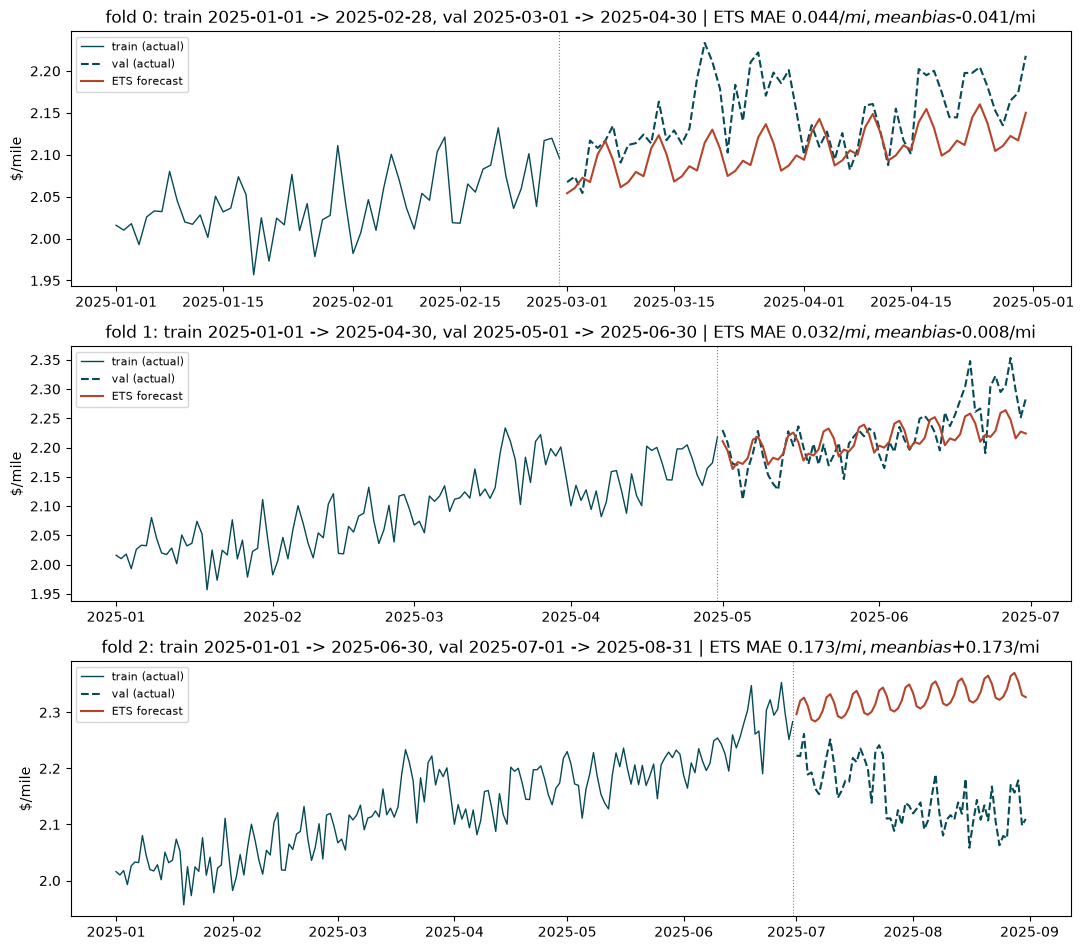

In [8]:
fig, axes = plt.subplots(len(result.folds), 1, figsize=(11, 3.2 * len(result.folds)), sharex=False)
for ax, fold in zip(axes, result.folds):
    daily_train = build_daily_index(fold.train)["rpm_median"]
    daily_val = build_daily_index(fold.val)["rpm_median"]
    horizon = len(daily_val)
    fc = pd.Series(ets_forecast(daily_train, horizon), index=daily_val.index)

    ax.plot(daily_train.index, daily_train, color="#064A56", lw=1, label="train (actual)")
    ax.plot(daily_val.index, daily_val, color="#064A56", lw=1.5, ls="--", label="val (actual)")
    ax.plot(fc.index, fc, color="#B5442A", lw=1.5, label="ETS forecast")
    ax.axvline(daily_train.index[-1], color="gray", lw=0.8, ls=":")

    fold_mae = mae(daily_val, fc)
    fold_bias = (fc - daily_val).mean()
    ax.set_title(
        f"fold {fold.index}: train {daily_train.index[0].date()} -> {daily_train.index[-1].date()}, "
        f"val {daily_val.index[0].date()} -> {daily_val.index[-1].date()} | "
        f"ETS MAE ${fold_mae:.3f}/mi, mean bias ${fold_bias:+.3f}/mi"
    )
    ax.set_ylabel("$/mile")
    ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

**Confirmed, but the mechanism is a genuine trend reversal, not a "hasn't-seen-enough-history"
problem.** Folds 0-1 show ETS slightly *under*-forecasting a steadily climbing series (small
negative bias, -$0.041/mi and -$0.008/mi), a damped trend being conservative while the real
series keeps climbing, unsurprising and mild. Fold 2 is different in kind: the true daily
level climbs the entire Jan-Jun training window (no flattening visible yet), then **reverses
and drops sharply right at the July 1 cutoff**, a peak-and-decline that isn't foreshadowed
anywhere in the training data. ETS's damped-trend forecast reasonably continues near the last
observed level (+$0.173/mi mean bias); no univariate method fit only on Jan-Jun (SARIMA and
drift would extrapolate the same climbing trend too) could have anticipated a reversal that
hadn't happened yet in its own history.

**Implication**: this isn't a fixable Stage-1 tuning bug, it's a structural limit of
history-only extrapolation at a real trend reversal. The final holdout (Sep-Oct) doesn't hit
this because its training pool runs through August, i.e. *past* the reversal: Stage 1 there
is extrapolating an already-established decline, not blindly guessing one is coming. The open
risk is whether the true Nov-Dec period contains a similar unforeshadowed reversal; nothing
in this dataset can rule that out in advance.

## 4. End-to-end CV evaluation (Stage 1 + Stage 2 combined)

Same 3 expanding-window folds, same `score()` metric (MAE/RMSE/SMAPE/MASE in dollar
`posted_rate` space, back-transformed) and same naive lane-median baseline as Pipeline A, so
the eventual comparison is apples-to-apples.

**Two different daily-level values are used deliberately.** Stage 2's target for *training*
rows uses the *actual* observed daily level for that date (already known, no leakage: day
groups average ~150 loads, so any one row's own influence on its day's median is negligible;
this is a considered simplification, not the OOF-safety concern the lane encoder needed at
n=1). At *scoring* time, predictions are reconstructed using Stage 1's *forecast* for
`fold.val`'s dates: the honest test, since Stage 1 has never seen those dates.

**No monotone constraint on distance.** Pipeline A constrained `distance`/`log_distance`
monotonically increasing because they carry ~94% of the raw log-rate signal (EDA §10). Here,
that dominant effect is explicitly divided out of the target (`posted_rate / (daily_level x
distance)`), so nothing says the *residual* relationship between distance and the offset has
to be monotonic, and forcing it would no longer be justified by the same reasoning.

In [9]:
LGB_PARAMS_STAGE2 = dict(
    objective="regression",
    metric="rmse",
    learning_rate=0.02,
    num_leaves=7,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=3000,
    random_state=RANDOM_STATE,
    verbose=-1,
)
STAGE2_EARLY_STOPPING_PATIENCE = 300


def fit_stage2_lgb(X_train, y_train, X_val, y_val):
    model = lgb.LGBMRegressor(**LGB_PARAMS_STAGE2)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=CATEGORICAL,
        callbacks=[lgb.early_stopping(STAGE2_EARLY_STOPPING_PATIENCE, verbose=False)],
    )
    return model


def combine_predictions(offset_pred_log, daily_level, distance):
    return np.exp(offset_pred_log) * daily_level * distance


def naive_lane_rpm_predict(fold_train_raw, apply_raw):
    rpm = fold_train_raw["posted_rate"] / fold_train_raw["distance"]
    lane_rpm = rpm.groupby([fold_train_raw["pickup"], fold_train_raw["delivery"]]).median()
    global_rpm = rpm.median()
    idx = pd.MultiIndex.from_arrays([apply_raw["pickup"], apply_raw["delivery"]])
    pred_rpm = lane_rpm.reindex(idx).to_numpy()
    pred_rpm = np.where(np.isnan(pred_rpm), global_rpm, pred_rpm)
    return pred_rpm * apply_raw["distance"].to_numpy()


def score(y_true_rate, pred_rate, naive_pred_rate):
    naive_mae = mae(y_true_rate, naive_pred_rate)
    return {
        "MAE": mae(y_true_rate, pred_rate),
        "RMSE": rmse(y_true_rate, pred_rate),
        "SMAPE": smape(y_true_rate, pred_rate),
        "MASE": mae(y_true_rate, pred_rate) / naive_mae,
        "naive_MAE": naive_mae,
    }

In [10]:
stage1_fn = STAGE1_CANDIDATES[BEST_STAGE1]

fold_results_b = []
for fold in result.folds:
    daily_train = build_daily_index(fold.train)["rpm_median"]
    daily_val_actual = build_daily_index(fold.val)["rpm_median"]
    horizon = len(daily_val_actual)
    stage1_fc = pd.Series(stage1_fn(daily_train, horizon), index=daily_val_actual.index)

    X_tr, X_va, feat_cols = build_shipment_features(fold.train, fold.val)
    train_level = fold.train["date"].map(daily_train)
    val_level_actual = fold.val["date"].map(daily_val_actual)
    y_tr = np.log(fold.train["posted_rate"] / (train_level.to_numpy() * fold.train["distance"].to_numpy()))
    y_va = np.log(fold.val["posted_rate"] / (val_level_actual.to_numpy() * fold.val["distance"].to_numpy()))

    model = fit_stage2_lgb(X_tr, y_tr, X_va, y_va)
    offset_pred = model.predict(X_va, num_iteration=model.best_iteration_)
    val_level_forecast = fold.val["date"].map(stage1_fc).to_numpy()
    pred_rate = combine_predictions(offset_pred, val_level_forecast, fold.val["distance"].to_numpy())

    naive_pred = naive_lane_rpm_predict(fold.train, fold.val)
    m = score(fold.val["posted_rate"].to_numpy(), pred_rate, naive_pred)
    m.update(fold=fold.index, n_train=len(fold.train), n_val=len(fold.val), best_iteration=model.best_iteration_)
    fold_results_b.append(m)

fold_df_b = pd.DataFrame(fold_results_b)[
    ["fold", "n_train", "n_val", "best_iteration", "MAE", "RMSE", "SMAPE", "MASE", "naive_MAE"]
]
display(fold_df_b.round(3))
print("\nmean:")
display(fold_df_b[["MAE", "RMSE", "SMAPE", "MASE"]].mean().round(3))

,fold,n_train,n_val,best_iteration,MAE,RMSE,SMAPE,MASE,naive_MAE
0,0,9255,9855,332,109.334,535.359,4.435,0.473,231.120
1,1,19110,9696,265,108.449,632.914,3.786,0.445,243.496
2,2,28806,9671,359,239.787,650.251,9.082,1.253,191.373



mean:


MAE      152.523
RMSE     606.175
SMAPE      5.767
MASE       0.724
dtype: float64

## 5. Final holdout evaluation (Sep-Oct, touched once)

Fit Stage 1 on the full Jan-Aug daily series and forecast forward across the holdout's date
range; fit Stage 2 on the full Jan-Aug pool, with `n_estimators` picked via the same
early-stopping-tail approach as Pipeline A (carve the last 2 months of the pool for early
stopping instead of reusing CV-fold iteration counts, Aug 23 bug fix). Combine, evaluate
once.

In [11]:
pool = clean[clean["date"] < "2025-09-01"]
holdout = result.holdout

daily_pool = build_daily_index(pool)["rpm_median"]
daily_holdout_index = build_daily_index(holdout).index
stage1_fc_holdout = pd.Series(stage1_fn(daily_pool, len(daily_holdout_index)), index=daily_holdout_index)

# Early-stopping tail, mirroring Pipeline A §4 / EDA §16's Jan-Jun -> Jul-Aug window.
es_tail_start = pool["date"].max() - pd.DateOffset(months=2) + pd.Timedelta(days=1)
es_fit = pool[pool["date"] < es_tail_start]
es_val = pool[pool["date"] >= es_tail_start]
print(f"early-stopping tail: fit on {len(es_fit)} rows (< {es_tail_start.date()}), "
      f"early-stop against {len(es_val)} rows (>= {es_tail_start.date()})")

X_es_fit, X_es_val, feat_cols = build_shipment_features(es_fit, es_val)
es_fit_level = es_fit["date"].map(daily_pool).to_numpy()
es_val_level = es_val["date"].map(daily_pool).to_numpy()
y_es_fit = np.log(es_fit["posted_rate"] / (es_fit_level * es_fit["distance"].to_numpy()))
y_es_val = np.log(es_val["posted_rate"] / (es_val_level * es_val["distance"].to_numpy()))

es_model = fit_stage2_lgb(X_es_fit, y_es_fit, X_es_val, y_es_val)
final_n_estimators_b = es_model.best_iteration_

X_pool, X_holdout, feat_cols = build_shipment_features(pool, holdout)
pool_level = pool["date"].map(daily_pool).to_numpy()
y_pool = np.log(pool["posted_rate"] / (pool_level * pool["distance"].to_numpy()))

final_params_b = dict(LGB_PARAMS_STAGE2, n_estimators=final_n_estimators_b)
final_model_b = lgb.LGBMRegressor(**final_params_b)
final_model_b.fit(X_pool, y_pool, categorical_feature=CATEGORICAL)

offset_pred_holdout = final_model_b.predict(X_holdout)
holdout_level_forecast = holdout["date"].map(stage1_fc_holdout).to_numpy()
holdout_pred_b = combine_predictions(offset_pred_holdout, holdout_level_forecast, holdout["distance"].to_numpy())

naive_pred_holdout = naive_lane_rpm_predict(pool, holdout)
holdout_score_b = score(holdout["posted_rate"].to_numpy(), holdout_pred_b, naive_pred_holdout)
print(f"early-stopping tail best_iteration -> final n_estimators={final_n_estimators_b}")
print("\nHOLDOUT (Sep-Oct), touched once, Pipeline B:")
for k, v in holdout_score_b.items():
    print(f"  {k:10s} {v:.3f}")

/tmp/ipykernel_29932/1042669960.py:9: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  es_tail_start = pool["date"].max() - pd.DateOffset(months=2) + pd.Timedelta(days=1)


early-stopping tail: fit on 28806 rows (< 2025-07-01), early-stop against 9671 rows (>= 2025-07-01)


early-stopping tail best_iteration -> final n_estimators=359

HOLDOUT (Sep-Oct), touched once, Pipeline B:
  MAE        105.786
  RMSE       632.507
  SMAPE      3.854
  MASE       0.544
  naive_MAE  194.497


## 5b. XGBoost variant: Stage 2 only, same config as Pipeline A's §4d

Same question as Pipeline A: does swapping LightGBM for XGBoost change anything? Stage 1
(ETS) is unrelated to the boosting-library question, so it's untouched; only Stage 2's
LightGBM is swapped for `xgb.XGBRegressor`, refit on the identical offset target
(`log(posted_rate / (daily_level x distance))`), same features, no monotone constraint (same
reasoning as §4: distance's dominant effect is already divided out of this target). Same
parameter-translation choices as Pipeline A's §4d: `learning_rate`/`subsample`/
`colsample_bytree`/early-stopping budget/`random_state` carried over 1:1, `max_depth=3`
standing in for `num_leaves=7`'s leaf budget, everything else left at XGBoost's defaults.

In [12]:
xgb_stage2_params = dict(
    n_estimators=3000,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    eval_metric="rmse",
    random_state=RANDOM_STATE,
)
XGB_EARLY_STOPPING_ROUNDS = 300

xgb_es_params_b = dict(xgb_stage2_params, early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS)
xgb_es_model_b = xgb.XGBRegressor(**xgb_es_params_b)
xgb_es_model_b.fit(X_es_fit, y_es_fit, eval_set=[(X_es_val, y_es_val)], verbose=False)
xgb_final_n_estimators_b = xgb_es_model_b.best_iteration + 1

xgb_final_params_b = dict(xgb_stage2_params, n_estimators=xgb_final_n_estimators_b)
xgb_final_model_b = xgb.XGBRegressor(**xgb_final_params_b)
xgb_final_model_b.fit(X_pool, y_pool)

xgb_offset_pred_holdout = xgb_final_model_b.predict(X_holdout)
xgb_holdout_pred_b = combine_predictions(xgb_offset_pred_holdout, holdout_level_forecast, holdout["distance"].to_numpy())
xgb_holdout_score_b = score(holdout["posted_rate"].to_numpy(), xgb_holdout_pred_b, naive_pred_holdout)

lib_compare_b = pd.DataFrame(
    {
        "LightGBM Stage 2 (this notebook's §5 model)": holdout_score_b,
        "XGBoost Stage 2 (same features/config, same ETS Stage 1)": xgb_holdout_score_b,
    }
).T[["MAE", "RMSE", "SMAPE", "MASE"]]
print(f"XGBoost Stage 2 best_iteration -> n_estimators={xgb_final_n_estimators_b} "
      f"(LightGBM used {final_n_estimators_b})")
display(lib_compare_b.round(3))

XGBoost Stage 2 best_iteration -> n_estimators=375 (LightGBM used 359)


,MAE,RMSE,SMAPE,MASE
LightGBM Stage 2 (this notebook's §5 model),105.786,632.507,3.854,0.544
"XGBoost Stage 2 (same features/config, same ETS Stage 1)",106.457,632.447,3.886,0.547


## 6. Diagnostics

In [13]:
diag_b = holdout.copy()
diag_b["pred"] = holdout_pred_b
diag_b["resid"] = diag_b["posted_rate"] - diag_b["pred"]

print("MAE by month:")
display(diag_b.groupby(diag_b["date"].dt.to_period("M")).apply(lambda g: mae(g["posted_rate"], g["pred"]), include_groups=False).round(2))

print("\nMAE by equipment:")
display(diag_b.groupby("equipment", observed=True).apply(lambda g: mae(g["posted_rate"], g["pred"]), include_groups=False).round(2))

dist_bucket = pd.cut(diag_b["distance"], bins=[0, 300, 700, 1500, 5000], labels=["<300mi", "300-700mi", "700-1500mi", ">1500mi"])
print("\nMAE by distance bucket:")
display(diag_b.groupby(dist_bucket, observed=True).apply(lambda g: mae(g["posted_rate"], g["pred"]), include_groups=False).round(2))

train_lanes = set(zip(pool["pickup"], pool["delivery"]))
diag_b["novel_lane"] = ~diag_b.apply(lambda r: (r["pickup"], r["delivery"]) in train_lanes, axis=1)
print("\nMAE by lane novelty:")
display(diag_b.groupby("novel_lane").apply(lambda g: mae(g["posted_rate"], g["pred"]), include_groups=False).round(2))
print("novel-lane share in this holdout:", diag_b["novel_lane"].mean().round(3))

MAE by month:


date
2025-09    103.61
2025-10    107.88
Freq: M, dtype: float64


MAE by equipment:


equipment
Dry Van    101.56
Flatbed    104.31
Reefer     116.34
dtype: float64


MAE by distance bucket:


distance
<300mi         24.70
300-700mi      61.46
700-1500mi     98.56
>1500mi       179.99
dtype: float64


MAE by lane novelty:


novel_lane
False    105.93
True      41.84
dtype: float64

novel-lane share in this holdout: 0.002


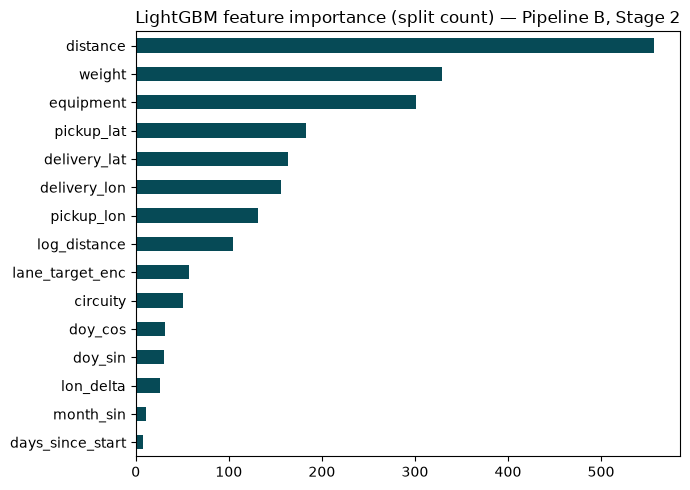

distance             557
weight               329
equipment            301
pickup_lat           183
delivery_lat         164
delivery_lon         156
pickup_lon           131
log_distance         104
lane_target_enc       57
circuity              51
doy_cos               31
doy_sin               30
lon_delta             26
month_sin             11
days_since_start       8
dow_sin                7
month_cos              5
dow_cos                3
is_weekend             0
days_to_new_year       0
days_to_christmas      0
dtype: int32

In [14]:
importances_b = pd.Series(final_model_b.feature_importances_, index=feat_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
importances_b.head(15).iloc[::-1].plot.barh(ax=ax, color="#064A56")
ax.set_title("LightGBM feature importance (split count), Pipeline B, Stage 2")
plt.tight_layout()
plt.show()
importances_b.round(1)

## 7. Pipeline A vs. Pipeline B

Pipeline A's numbers are the Aug 24 holdout results (`pipeline_a.ipynb`, shrinkage encoder,
same Jan-Aug pool -> Sep-Oct holdout). Naive and linear baselines recomputed here directly
for a self-contained comparison.

In [15]:
from sklearn.linear_model import LinearRegression

Xb = pd.concat([np.log1p(pool[["distance"]]), pd.get_dummies(pool["equipment"], drop_first=True)], axis=1).astype(float)
Xh = pd.concat([np.log1p(holdout[["distance"]]), pd.get_dummies(holdout["equipment"], drop_first=True)], axis=1).astype(float)[Xb.columns]
lin = LinearRegression().fit(Xb, np.log1p(pool["posted_rate"]))
lin_pred = np.expm1(lin.predict(Xh))
lin_score = score(holdout["posted_rate"].to_numpy(), lin_pred, naive_pred_holdout)

lane_score = score(holdout["posted_rate"].to_numpy(), naive_pred_holdout, naive_pred_holdout)

# Pipeline A numbers as of Aug 25 (pipeline_a.ipynb §4/§4d), including the `market_trend`
# feature (STL trend + damped-Holt forecast of the daily $/mile level, used as an always-on
# Stage-2-style feature rather than a target-divisor) added after this notebook's Aug 24
# baseline, plus the XGBoost variant added the same day. Hardcoded here since pipeline_a.ipynb
# and pipeline_b.ipynb are separate notebook kernels.
PIPELINE_A_LGB_HOLDOUT = {"MAE": 109.930, "RMSE": 633.447, "SMAPE": 3.979, "MASE": 0.565}
PIPELINE_A_XGB_HOLDOUT = {"MAE": 106.897, "RMSE": 632.658, "SMAPE": 3.853, "MASE": 0.550}

compare = pd.DataFrame(
    {
        "lane-median $/mi x distance (naive)": lane_score,
        "linear log-rate ~ log-dist+eq": lin_score,
        "Pipeline A, LightGBM (+ market_trend)": {**PIPELINE_A_LGB_HOLDOUT, "naive_MAE": lane_score["naive_MAE"]},
        "Pipeline A, XGBoost (+ market_trend)": {**PIPELINE_A_XGB_HOLDOUT, "naive_MAE": lane_score["naive_MAE"]},
        "Pipeline B, LightGBM Stage 2": holdout_score_b,
        "Pipeline B, XGBoost Stage 2": xgb_holdout_score_b,
    }
).T[["MAE", "RMSE", "SMAPE", "MASE"]]
display(compare.round(3))
print("\nNote: the A/B gap has closed substantially since the Aug 24 baseline; see the")
print("summary below for the full before/after and the current recommendation.")

,MAE,RMSE,SMAPE,MASE
lane-median $/mi x distance (naive),194.497,658.216,7.468,1.000
linear log-rate ~ log-dist+eq,134.589,639.768,5.156,0.692
"Pipeline A, LightGBM (+ market_trend)",109.930,633.447,3.979,0.565
"Pipeline A, XGBoost (+ market_trend)",106.897,632.658,3.853,0.550
"Pipeline B, LightGBM Stage 2",105.786,632.507,3.854,0.544
"Pipeline B, XGBoost Stage 2",106.457,632.447,3.886,0.547



Note: the A/B gap has closed substantially since the Aug 24 baseline; see the
summary below for the full before/after and the current recommendation.


## Summary: Pipeline B results

**Stage 1 winner: ETS (damped trend + weekly seasonal).** Backtest mean MAE across the 3
CV folds: **ETS $0.083/mi**, drift $0.088/mi, SARIMA(1,1,1)(1,1,1)_7 $0.089/mi,
seasonal-naive $0.091/mi, `stl_trend` (STL trend + damped Holt, Aug 25 addition, the same
method `pipeline_a.ipynb`'s `market_trend` feature uses, tried here as a Stage 1 candidate in
its own right) $0.111/mi, worst of the five, and notably worse than ETS specifically at
fold 2's trend reversal (0.232 vs. 0.173/mi), the opposite of the hypothesis that dropping
seasonality would make it more robust there (see §3b's finding note for why). ETS remains
selected. All non-`stl_trend` candidates beat each other by a small margin: the daily
series is noisy enough (n~150 loads/day) that simple damped-trend smoothing edges out the
more complex SARIMA fit, consistent with the general finding that simple baselines are
shockingly strong and ETS in particular is a great baseline.

**End-to-end CV (§4) is uneven across folds.** Fold 2 (train Jan-Jun, val Jul-Aug) scores
MASE 1.253, *worse* than the naive lane-median baseline, while folds 0-1 score MASE
0.47-0.45. Likely cause: EDA's "soft mid-year bump" (monthly mean rate rises Jan→Jun before
easing toward Oct) sits right in fold 2's forecast horizon. An ETS model trained only on
Jan-Jun history has to extrapolate through the peak it hasn't fully seen yet, whereas the
final holdout's Stage 1 fit (trained on the *full* Jan-Aug pool, past the peak) forecasts the
calmer Sep-Oct decline instead. Flagged here rather than smoothed over; doesn't change the
headline result below since the untouched holdout is the metric that governs model choice,
but worth knowing if the market pattern between Aug 22 (Jan-Aug case, EDA §16) resurfaces
around any future mid-year peak.

**Final holdout (Sep-Oct, touched once), updated Aug 25: the gap has closed substantially.**

| Model | MAE | RMSE | SMAPE | MASE |
|---|---|---|---|---|
| lane-median $/mi x distance (naive) | $194.50 | $658.22 | 7.47% | 1.000 |
| linear log-rate ~ log-dist + equipment | $134.59 | $639.77 | 5.16% | 0.692 |
| Pipeline A, LightGBM (+ `market_trend`, Aug 25) | $109.93 | $633.45 | 3.98% | 0.565 |
| Pipeline A, XGBoost (+ `market_trend`, Aug 25) | $106.90 | $632.66 | 3.85% | 0.550 |
| **Pipeline B, LightGBM Stage 2 (this notebook)** | **$105.79** | **$632.51** | **3.85%** | **0.544** |
| Pipeline B, XGBoost Stage 2 (§5b) | $106.46 | $632.45 | 3.89% | 0.547 |

At this notebook's original Aug 24 baseline, Pipeline B beat Pipeline A by ~17% MAE. Two
things closed most of that gap since: Pipeline A gained a `market_trend` feature (STL trend +
damped-Holt forecast of the same daily $/mile level Stage 1 forecasts here, but used as an
input feature rather than a target-divisor) that alone took it from $128.09 to $109.93, and
swapping XGBoost in for Pipeline A's LightGBM took it to $106.90, within ~1% of Pipeline B.
Pipeline B's own XGBoost swap (§5b) was a wash ($106.46, no real change). **Pipeline
B/LightGBM is still the best single model, but no longer by a wide margin.**

**Diagnostics**: mild MAE degradation Sep ($103.61) -> Oct ($107.88), matching Pipeline A's
same-direction (if larger) drift; Reefer remains the hardest equipment ($116.34); dollar MAE
scales with distance bucket as expected ($24.70 short-haul -> $179.99 long-haul, all lower
than Pipeline A's corresponding buckets). Novel-lane MAE ($41.84) is again lower than
seen-lane ($105.93) in this holdout's tiny 0.2%-novel sample, consistent with Pipeline A's
Aug 24 finding that the shrinkage lane encoder fixed novel-lane generalization; not
independently re-validated here with a leave-lane-out split (Pipeline A's §6 already did
that for the shared lane-encoding logic both pipelines use).

**Feature importance**: `distance` still leads (557 splits) even with the dominant distance
effect divided out of the target. The residual, non-monotonic-constrained relationship
(short-haul minimum-charge effects, EDA's noted flatness of $/mile vs. distance) is still the
single most-split-on feature, followed by `weight` (329) and `equipment` (301).
`lane_target_enc` sits at 57 splits, in the same mid-pack range as Pipeline A's shrunk
encoder (76): consistent, not dominating either model.

**Conclusion: Pipeline B is still the pick, but the margin over Pipeline A is now small
(~1% against A's best XGBoost variant, not the original 17%).** Fold 2's Stage-1 forecast
issue is root-caused (a genuine, unforeshadowed trend reversal, see §3c/§3b's finding notes)
rather than fixable by retuning; a seasonality-free alternative (`stl_trend`) was tried and
made it worse, not better. Given how close the architectures now are, the ensemble question
from the original conclusion here is worth re-running with the updated numbers before
finalizing which model produces the December predictions (see `pipeline_c.ipynb`).